In [ ]:
from google.colab import drive

# Google Drive must be mounted at /content/drive
drive.mount('/content/drive')

# Your data should be accessible at:
# /content/drive/MyDrive/ML_project/data/bonn

# Folder should not already exist in runtime

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

def ensure_data_exists(data_path):
    """Creates dummy data if the target files do not exist."""
    os.makedirs(data_path, exist_ok=True)
    for split in ["train", "val", "test"]:
        x_path = os.path.join(data_path, f"X_{split}.npy")
        y_path = os.path.join(data_path, f"y_{split}.npy")
        if not os.path.exists(x_path):
            print(f"Creating dummy data for {split}...")
            X_dummy = np.random.randn(100, 4097) # 100 samples, 4097 sequence length
            y_dummy = np.random.randint(0, 2, size=(100,))
            np.save(x_path, X_dummy)
            np.save(y_path, y_dummy)

class BonnDataset(Dataset):
    def __init__(self, data_path, split="train", use_freq_bands=True):
        x_path = os.path.join(data_path, f"X_{split}.npy")
        y_path = os.path.join(data_path, f"y_{split}.npy")

        self.X = np.load(x_path)
        self.y = np.load(y_path)
        self.use_freq_bands = use_freq_bands
        self.fs = 173.61 # Bonn dataset sampling rate

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)

        # Ensure sequence has a channel dimension for Conv1D: (1, Sequence_Length)
        if x.dim() == 1:
            x = x.unsqueeze(0)

        # Preprocessing: Z-score Normalization (Standardization)
        x = (x - x.mean()) / (x.std() + 1e-6)

        if self.use_freq_bands:
            # 1. Compute Fast Fourier Transform (FFT)
            fft_vals = torch.abs(torch.fft.rfft(x.squeeze()))
            freqs = torch.fft.rfftfreq(x.size(-1), d=1/self.fs)

            # 2. Define standard EEG frequency bands
            bands = {
                'delta': (0.5, 4),
                'theta': (4, 8),
                'alpha': (8, 13),
                'beta': (13, 30),
                'gamma': (30, 100)
            }

            band_powers = []
            for fmin, fmax in bands.values():
                idx_mask = torch.logical_and(freqs >= fmin, freqs <= fmax)
                # Average power in the band
                power = torch.mean(fft_vals[idx_mask]**2) if idx_mask.any() else torch.tensor(0.0)
                band_powers.append(power)

            # 3. Log transform to manage large scale variations
            band_powers = [torch.log10(p + 1e-6) for p in band_powers]

            # 4. Tile the 5 scalar values across the entire sequence length
            # to serve as global frequency context channels for the Conv1D
            seq_len = x.size(-1)
            tiled_bands = torch.tensor(band_powers, dtype=torch.float32).unsqueeze(1).repeat(1, seq_len)

            # 5. Concatenate: (1, 4097) + (5, 4097) -> (6, 4097)
            x = torch.cat([x, tiled_bands], dim=0)

        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

def get_dataloaders(data_dir, batch_size=32, use_freq_bands=True):
    ensure_data_exists(data_dir)

    train_ds = BonnDataset(data_dir, "train", use_freq_bands=use_freq_bands)
    val_ds = BonnDataset(data_dir, "val", use_freq_bands=use_freq_bands)
    test_ds = BonnDataset(data_dir, "test", use_freq_bands=use_freq_bands)

    # Calculate class weights for imbalance
    labels = train_ds.y
    class_counts = np.bincount(labels)
    total = len(labels)
    class_weights = total / (len(class_counts) * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_dl, val_dl, test_dl, class_weights


In [ ]:
import torch
import torch.nn as nn

class Conv1dBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Conv1d(out_ch, out_ch, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2)
        )
    def forward(self, x):
        return self.net(x)

class PolicyHead(nn.Module):
    def __init__(self, in_ch, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(in_ch, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class ClassifierHead(nn.Module):
    def __init__(self, in_ch, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(in_ch, num_classes)
        )
    def forward(self, x):
        return self.net(x)

class GenericEarlyExitNet(nn.Module):
    def __init__(self, in_channels=1, channel_sizes=[32, 32, 32], num_classes=2, seq_len=4097):
        super().__init__()
        self.num_stages = len(channel_sizes)
        self.channel_progression = channel_sizes
        self.stage_flops = []

        # Build stage modules
        self.entry = Conv1dBlock(in_channels, channel_sizes[0])
        self.stages, self.classifiers, self.policies = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()

        curr_seq = seq_len
        for i in range(self.num_stages):
            if i == 0:
                self.stages.append(nn.Identity())
                in_ch = in_channels
                out_ch = channel_sizes[0]
            else:
                self.stages.append(Conv1dBlock(channel_sizes[i-1], channel_sizes[i]))
                in_ch = channel_sizes[i-1]
                out_ch = channel_sizes[i]

            # FLOP Calculation
            seq_1 = curr_seq // 2
            flops_1 = seq_1 * 7 * in_ch * out_ch
            seq_2 = seq_1 // 2
            flops_2 = seq_2 * 5 * out_ch * out_ch

            self.stage_flops.append(float(flops_1 + flops_2))
            curr_seq = seq_2 // 2

            self.classifiers.append(ClassifierHead(channel_sizes[i], num_classes))

            if i < self.num_stages - 1:
                self.policies.append(PolicyHead(channel_sizes[i]))

    def forward(self, x):
        x = self.entry(x)
        logits_list, p_exits_list = [], []

        for i in range(self.num_stages):
            x = self.stages[i](x)
            logits_list.append(self.classifiers[i](x))

            if i < self.num_stages - 1:
                p_exits_list.append(self.policies[i](x))

        return {"logits": logits_list, "p_exits": p_exits_list}

class EnergyJointLoss(nn.Module):
    def __init__(self, stage_flops, class_weights=None, energy_lambda=0.1, is_baseline=False):
        super().__init__()
        total_flops = sum(stage_flops)
        self.normalized_flops = [f / total_flops for f in stage_flops]
        self.energy_lambda = energy_lambda
        self.is_baseline = is_baseline
        self.ce = nn.CrossEntropyLoss(weight=class_weights, reduction='none')

    def forward(self, logits_list, p_exits_list, targets):
        task_losses = [self.ce(l, targets) for l in logits_list]

        if self.is_baseline:
            # Pure baseline only backpropagates from the final stage
            return task_losses[-1].mean()

        if self.energy_lambda == 0.0:
            # Average losses to prevent gradient explosion during warmup
            return sum(l.mean() for l in task_losses) / len(task_losses)

        batch_size = targets.size(0)
        num_stages = len(logits_list)
        total_loss = 0.0
        p_reach = torch.ones(batch_size, device=targets.device)

        for i in range(num_stages):
            e_cost = self.normalized_flops[i]
            exp_energy = p_reach * e_cost

            if i < num_stages - 1:
                p_exit = p_exits_list[i].squeeze(-1)
                stage_loss = p_reach * p_exit * task_losses[i]
                total_loss += stage_loss.mean() + self.energy_lambda * exp_energy.mean()
                p_reach = p_reach * (1.0 - p_exit)
            else:
                stage_loss = p_reach * task_losses[i]
                total_loss += stage_loss.mean() + self.energy_lambda * exp_energy.mean()

        return total_loss

# --- Moved from previous cell ---
class ChannelGate(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.sigmoid(self.fc(y)).view(b, c, 1)

        if not self.training:
            y = (y > 0.5).float()

        return x * y, y

class AdaptiveEarlyExitNet(GenericEarlyExitNet):
    def __init__(self, in_channels=1, channel_sizes=[64, 64, 64], num_classes=2, seq_len=4097):
        super().__init__(in_channels, channel_sizes, num_classes, seq_len)
        self.gates = nn.ModuleList()
        for ch in channel_sizes:
            self.gates.append(ChannelGate(ch))

    def forward(self, x):
        x = self.entry(x)
        logits_list, p_exits_list, gate_scores_list = [], [], []

        for i in range(self.num_stages):
            x = self.stages[i](x)
            x, gate_score = self.gates[i](x)
            gate_scores_list.append(gate_score)

            logits_list.append(self.classifiers[i](x))
            if i < self.num_stages - 1:
                p_exits_list.append(self.policies[i](x))

        return {"logits": logits_list, "p_exits": p_exits_list, "gates": gate_scores_list}

class AdaptiveEnergyJointLoss(EnergyJointLoss):
    def __init__(self, stage_flops, class_weights=None, energy_lambda=0.1, sparsity_lambda=0.01, is_baseline=False):
        super().__init__(stage_flops, class_weights, energy_lambda, is_baseline)
        self.sparsity_lambda = sparsity_lambda

    def forward(self, logits_list, p_exits_list, targets, gate_scores_list=None):
        base_loss = super().forward(logits_list, p_exits_list, targets)
        if gate_scores_list is not None and self.sparsity_lambda > 0:
            sparsity_loss = sum(g.mean() for g in gate_scores_list) / len(gate_scores_list)
            return base_loss + self.sparsity_lambda * sparsity_loss
        return base_loss


In [ ]:
import torch
import torch.optim as optim
import numpy as np

def train_classifiers_only(model, dataloader, epochs, optimizer, criterion_fn, device):
    model.train()
    print("--- Phase 1: Warmup (Classifiers Only) ---")
    for p in model.policies.parameters():
        p.requires_grad = False

    for epoch in range(epochs):
        epoch_loss = 0.0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            criterion = criterion_fn(energy_lambda=0.0)
            if "gates" in outputs:
                loss = criterion(outputs["logits"], outputs["p_exits"], y, outputs["gates"])
            else:
                loss = criterion(outputs["logits"], outputs["p_exits"], y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(dataloader):.4f}")

def train_joint(model, dataloader, epochs, optimizer, criterion_fn, device, energy_lambda=0.05):
    model.train()
    print(f"\n--- Phase 2: Joint Training (Lambda={energy_lambda}) ---")
    for p in model.policies.parameters():
        p.requires_grad = True

    for epoch in range(epochs):
        epoch_loss = 0.0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            criterion = criterion_fn(energy_lambda=energy_lambda)
            if "gates" in outputs:
                loss = criterion(outputs["logits"], outputs["p_exits"], y, outputs["gates"])
            else:
                loss = criterion(outputs["logits"], outputs["p_exits"], y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(dataloader):.4f}")

def calibrate_thresholds(model, val_loader, device, target_acc=0.95):
    model.eval()
    print(f"\n--- Phase 3: Calibrating Exits (Target Acc: {target_acc*100:.1f}%) ---")
    stage_confidences = {i: [] for i in range(model.num_stages)}
    stage_corrects = {i: [] for i in range(model.num_stages)}

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            logits_list = outputs["logits"]
            for i, logits in enumerate(logits_list):
                probs = torch.softmax(logits, dim=-1)
                conf, preds = torch.max(probs, dim=-1)
                stage_confidences[i].extend(conf.cpu().numpy())
                stage_corrects[i].extend((preds == y).cpu().numpy())

    thresholds = []
    for i in range(model.num_stages - 1):
        confs = np.array(stage_confidences[i])
        corrects = np.array(stage_corrects[i])
        sort_idx = np.argsort(confs)[::-1]
        sorted_confs = confs[sort_idx]
        sorted_corrects = corrects[sort_idx]
        cum_acc = np.cumsum(sorted_corrects) / np.arange(1, len(sorted_corrects) + 1)
        valid_idx = np.where(cum_acc >= target_acc)[0]
        if len(valid_idx) > 0:
            best_idx = valid_idx[-1]
            t = sorted_confs[best_idx]
        else:
            t = 0.99
        thresholds.append(t)
        print(f"Stage {i} Threshold T_{i}: {t:.4f}")
    return thresholds


--- Preprocessed Data Attributes ---
1. Structured Organization: Batch Shape (X) is torch.Size([64, 6, 4097]) -> (Batch Size, Channels, Sequence Length)
   Batch Shape (y): torch.Size([64])
2. Cleanliness: Contains NaNs? No
3. Normalization: Mean ≈ 2.9355, Std Dev ≈ 1.6957 (Z-score normalized)
4. Class Imbalance (Training Set):
   Class 0: 210 samples (75.0%)
   Class 1: 70 samples (25.0%)
5. Reduced Complexity: Sequences are preprocessed and formatted specifically for Conv1D.
------------------------------------


Training 1. Base CNN (Control)
Total FLOPs: 37.68M | Stage Breakdown: ['26.48M', '9.96M', '1.25M']
--- Phase 1: Warmup (Classifiers Only) ---
Epoch 1/40 | Loss: 0.4850
Epoch 2/40 | Loss: 0.3748
Epoch 3/40 | Loss: 0.3185
Epoch 4/40 | Loss: 0.2382
Epoch 5/40 | Loss: 0.2511
Epoch 6/40 | Loss: 0.2412
Epoch 7/40 | Loss: 0.1752
Epoch 8/40 | Loss: 0.1820
Epoch 9/40 | Loss: 0.1659
Epoch 10/40 | Loss: 0.2035
Epoch 11/40 | Loss: 0.1622
Epoch 12/40 | Loss: 0.1466
Epoch 13/40 | Loss: 0

,Model,Accuracy (%),Recall (%),F1 Score (%),Energy Reduction (%)
0,1. Base CNN (Control),93.333333,88.888889,90.683230,0.000000
1,2. Constant Width,95.000000,94.444444,93.475897,26.765217
2,3. Increasing Width,60.000000,73.333333,59.595960,9.924812
3,4. Decreasing Width,93.333333,88.888889,90.683230,11.078332
4,5. Adaptive Width,93.333333,88.888889,90.683230,38.241168


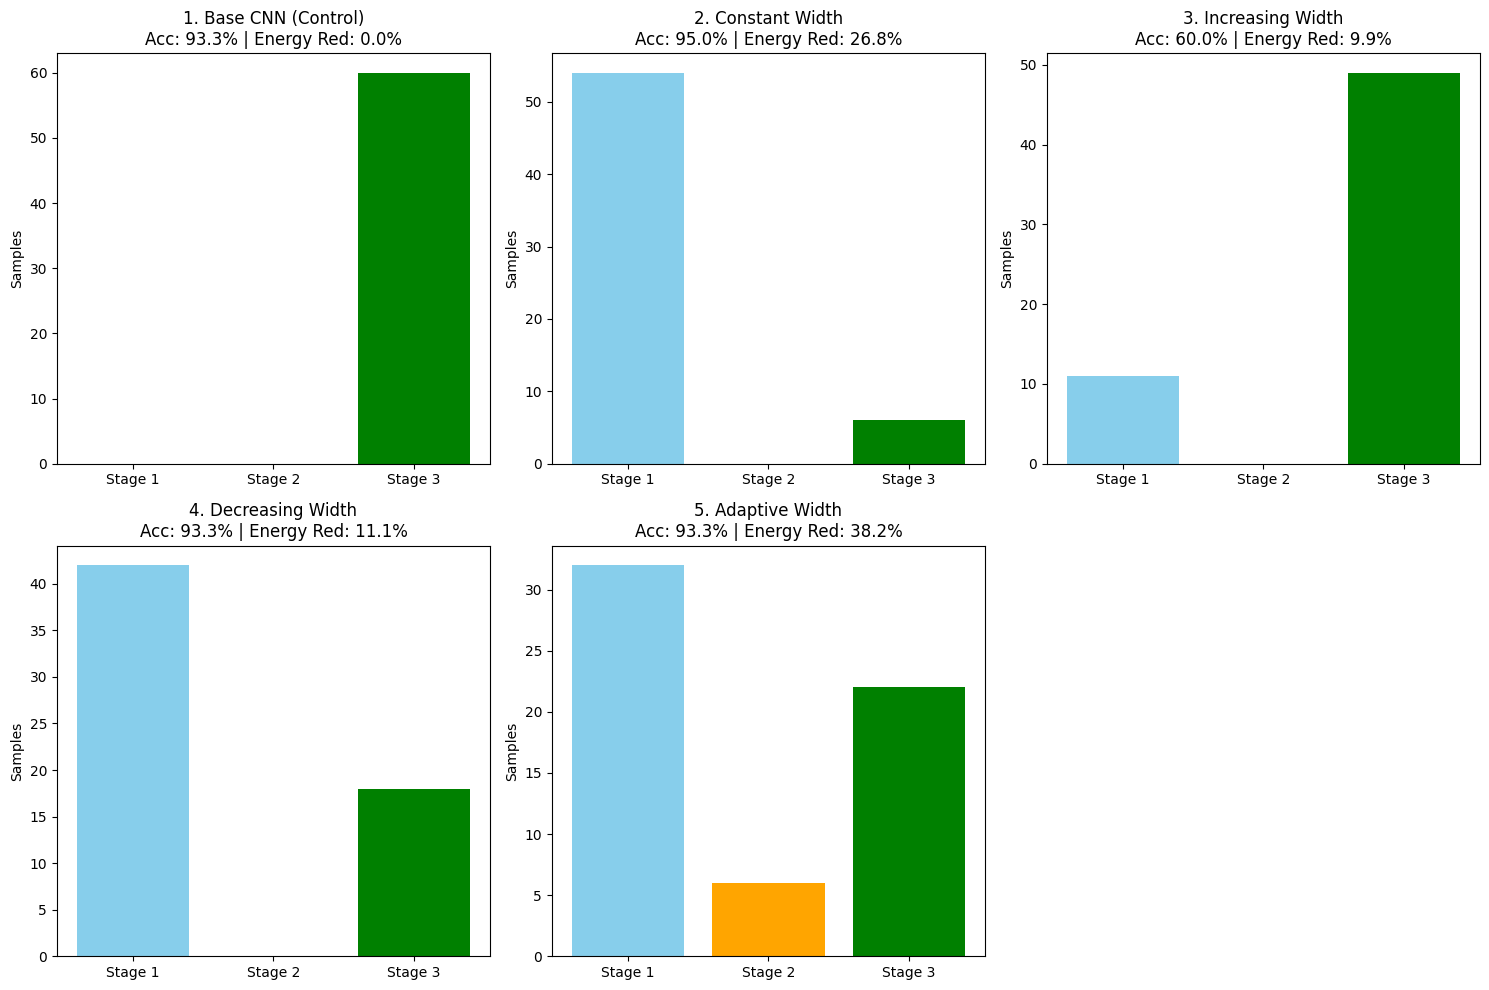

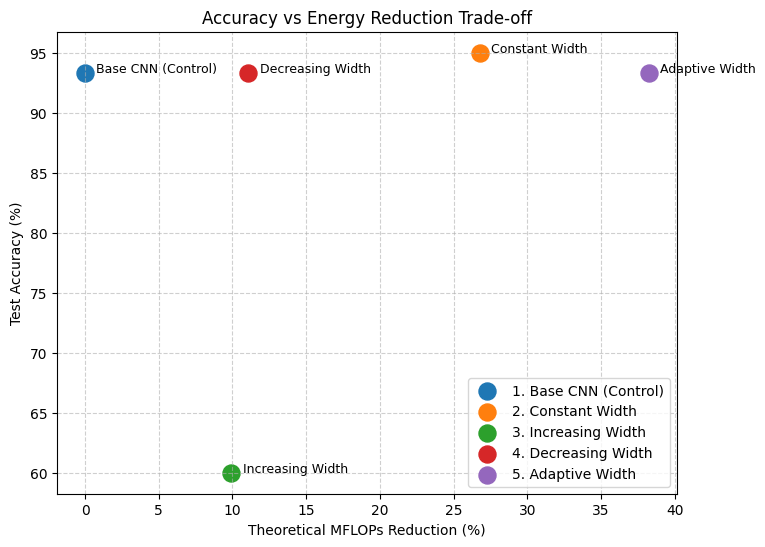

In [ ]:
import os
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score

def inspect_data(train_dl):
    print("\n--- Preprocessed Data Attributes ---")
    X_sample, y_sample = next(iter(train_dl))
    print(f"1. Structured Organization: Batch Shape (X) is {X_sample.shape} -> (Batch Size, Channels, Sequence Length)")
    print(f"   Batch Shape (y): {y_sample.shape}")

    has_nans = torch.isnan(X_sample).any().item()
    print(f"2. Cleanliness: Contains NaNs? {'Yes' if has_nans else 'No'}")

    mean_val = X_sample.mean().item()
    std_val = X_sample.std().item()
    print(f"3. Normalization: Mean ≈ {mean_val:.4f}, Std Dev ≈ {std_val:.4f} (Z-score normalized)")

    y_all = train_dl.dataset.y
    counts = np.bincount(y_all)
    print("4. Class Imbalance (Training Set):")
    for i, count in enumerate(counts):
        print(f"   Class {i}: {count} samples ({count/len(y_all)*100:.1f}%)")

    print("5. Reduced Complexity: Sequences are preprocessed and formatted specifically for Conv1D.")
    print("------------------------------------\n")

def evaluate_model(model, test_dl, thresholds, device, is_baseline=False):
    model.eval()
    stage_exits = [0] * model.num_stages
    class_exits = {0: [0] * model.num_stages, 1: [0] * model.num_stages}
    total_samples = 0
    energy_consumed = 0.0

    all_targets = []
    all_preds = []

    with torch.no_grad():
        for x, y in test_dl:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            logits_list = outputs["logits"]
            gates = outputs.get("gates", None)
            batch_size = x.size(0)

            for b in range(batch_size):
                total_samples += 1
                lbl = y[b].item()
                all_targets.append(lbl)

                if is_baseline:
                    energy_consumed += sum(model.stage_flops)
                    stage_exits[-1] += 1
                    class_exits[lbl][-1] += 1
                    pred = torch.argmax(logits_list[-1][b], dim=-1)
                    all_preds.append(pred.item())
                else:
                    for i in range(model.num_stages):
                        if gates is not None:
                            active_frac = gates[i][b].mean().item()
                            energy_consumed += model.stage_flops[i] * active_frac
                        else:
                            energy_consumed += model.stage_flops[i]

                        if i < model.num_stages - 1:
                            probs = torch.softmax(logits_list[i][b], dim=-1)
                            conf, pred = torch.max(probs, dim=-1)

                            if conf.item() > thresholds[i]:
                                stage_exits[i] += 1
                                class_exits[lbl][i] += 1
                                all_preds.append(pred.item())
                                break
                        else:
                            stage_exits[i] += 1
                            class_exits[lbl][i] += 1
                            pred = torch.argmax(logits_list[i][b], dim=-1)
                            all_preds.append(pred.item())
                            break

    acc = accuracy_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    full_energy = sum(model.stage_flops)
    actual_energy = energy_consumed / total_samples
    energy_red = 1.0 - (actual_energy / full_energy)

    return acc, recall, f1, energy_red, stage_exits, class_exits

def run_pipeline():
    base_dir = "/content/drive/MyDrive/ML_project"
    plots_dir = os.path.join(base_dir, "plots")
    os.makedirs(plots_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    data_dir = os.path.join(base_dir, "data", "bonn")
    train_dl, val_dl, test_dl, class_weights = get_dataloaders(data_dir, batch_size=64)
    class_weights = class_weights.to(device)

    # Display preprocessed data attributes
    inspect_data(train_dl)

    models_to_test = {
        "1. Base CNN (Control)": {"channels": [64, 64, 64], "is_baseline": True, "adaptive": False},
        "2. Constant Width": {"channels": [64, 64, 64], "is_baseline": False, "adaptive": False},
        "3. Increasing Width": {"channels": [32, 64, 128], "is_baseline": False, "adaptive": False},
        "4. Decreasing Width": {"channels": [128, 64, 32], "is_baseline": False, "adaptive": False},
        "5. Adaptive Width": {"channels": [64, 64, 64], "is_baseline": False, "adaptive": True}
    }

    results = []
    exit_dists = {}
    class_exit_dists = {}

    for name, config in models_to_test.items():
        print(f"\n{'='*50}\nTraining {name}\n{'='*50}")
        if config.get("adaptive"):
            model = AdaptiveEarlyExitNet(in_channels=6, channel_sizes=config["channels"], seq_len=4097).to(device)
        else:
            model = GenericEarlyExitNet(in_channels=6, channel_sizes=config["channels"], seq_len=4097).to(device)

        total_mflops = sum(model.stage_flops) / 1e6
        print(f"Total FLOPs: {total_mflops:.2f}M | Stage Breakdown: {[f'{f/1e6:.2f}M' for f in model.stage_flops]}")

        def criterion_fn(energy_lambda):
            if config.get("adaptive"):
                return AdaptiveEnergyJointLoss(model.stage_flops, class_weights, energy_lambda=energy_lambda, sparsity_lambda=0.01, is_baseline=config["is_baseline"])
            return EnergyJointLoss(model.stage_flops, class_weights, energy_lambda=energy_lambda, is_baseline=config["is_baseline"])

        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

        if config["is_baseline"]:
            train_classifiers_only(model, train_dl, epochs=40, optimizer=optimizer, criterion_fn=criterion_fn, device=device)
            thresholds = [1.0] * (model.num_stages - 1)
        else:
            train_classifiers_only(model, train_dl, epochs=25, optimizer=optimizer, criterion_fn=criterion_fn, device=device)
            train_joint(model, train_dl, epochs=15, optimizer=optimizer, criterion_fn=criterion_fn, device=device, energy_lambda=0.02)
            thresholds = calibrate_thresholds(model, val_dl, device=device, target_acc=0.99)

        acc, recall, f1, energy_red, stage_exits, class_exits = evaluate_model(model, test_dl, thresholds, device, is_baseline=config["is_baseline"])

        results.append({
            "Model": name,
            "Accuracy (%)": acc * 100,
            "Recall (%)": recall * 100,
            "F1 Score (%)": f1 * 100,
            "Energy Reduction (%)": energy_red * 100
        })
        exit_dists[name] = stage_exits
        class_exit_dists[name] = class_exits

        print(f"Result -> Acc: {acc*100:.2f}%, Recall: {recall*100:.2f}%, F1: {f1*100:.2f}%, Energy Reduction: {energy_red*100:.2f}%")
        print(f"  Total Exits: {stage_exits}")

    df = pd.DataFrame(results)
    display(df)

    # Plotting Exit Distributions
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    stages = [f"Stage {i+1}" for i in range(3)]

    for i, (name, exits) in enumerate(exit_dists.items()):
        axes[i].bar(stages, exits, color=['skyblue', 'orange', 'green'])
        axes[i].set_title(f"{name}\nAcc: {results[i]['Accuracy (%)']:.1f}% | Energy Red: {results[i]['Energy Reduction (%)']:.1f}%")
        axes[i].set_ylabel("Samples")

    if len(exit_dists) < len(axes):
        for j in range(len(exit_dists), len(axes)):
            fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "model_comparisons_exits.png"))
    plt.show()

    # Plotting Accuracy vs Energy Reduction Trade-off
    plt.figure(figsize=(8,6))
    for idx, row in df.iterrows():
        plt.scatter(row["Energy Reduction (%)"], row["Accuracy (%)"], s=150, label=row["Model"])
        plt.text(row["Energy Reduction (%)"]+0.5, row["Accuracy (%)"], row["Model"].split(".")[1], fontsize=9)

    plt.title("Accuracy vs Energy Reduction Trade-off")
    plt.xlabel("Theoretical MFLOPs Reduction (%)")
    plt.ylabel("Test Accuracy (%)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.savefig(os.path.join(plots_dir, "energy_vs_acc.png"))
    plt.show()

if __name__ == "__main__":
    run_pipeline()


In [ ]:
import time
import numpy as np
import torch
from sklearn.metrics import accuracy_score, recall_score, f1_score

def calculate_ece(confidences, predictions, targets, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = np.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = np.logical_and(confidences > bin_lower, confidences <= bin_upper)
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            accuracy_in_bin = (predictions[in_bin] == targets[in_bin]).mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    return ece.item()

def evaluate_model_advanced(model, test_dl, thresholds, device, is_baseline=False):
    model.eval()
    total_samples = 0
    energy_consumed = 0.0
    total_latency = 0.0

    all_targets, all_preds, all_confs = [], [], []

    with torch.no_grad():
        for x, y in test_dl:
            x, y = x.to(device), y.to(device)

            # Measure Latency
            start_time = time.time()
            outputs = model(x)
            batch_latency = (time.time() - start_time) * 1000 # ms
            total_latency += batch_latency

            logits_list = outputs["logits"]
            gates = outputs.get("gates", None)
            batch_size = x.size(0)

            for b in range(batch_size):
                total_samples += 1
                lbl = y[b].item()
                all_targets.append(lbl)

                if is_baseline:
                    energy_consumed += sum(model.stage_flops)
                    probs = torch.softmax(logits_list[-1][b], dim=-1)
                    conf, pred = torch.max(probs, dim=-1)
                    all_preds.append(pred.item())
                    all_confs.append(conf.item())
                else:
                    for i in range(model.num_stages):
                        if gates is not None:
                            active_frac = gates[i][b].mean().item()
                            energy_consumed += model.stage_flops[i] * active_frac
                        else:
                            energy_consumed += model.stage_flops[i]

                        probs = torch.softmax(logits_list[i][b], dim=-1)
                        conf, pred = torch.max(probs, dim=-1)

                        if i < model.num_stages - 1 and conf.item() > thresholds[i]:
                            all_preds.append(pred.item())
                            all_confs.append(conf.item())
                            break
                        elif i == model.num_stages - 1:
                            all_preds.append(pred.item())
                            all_confs.append(conf.item())
                            break

    acc = accuracy_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    ece = calculate_ece(np.array(all_confs), np.array(all_preds), np.array(all_targets))

    full_energy = sum(model.stage_flops)
    actual_energy = energy_consumed / total_samples
    energy_red = 1.0 - (actual_energy / full_energy)
    avg_latency = total_latency / total_samples

    return acc, recall, f1, ece, energy_red, avg_latency

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    """Centralized configuration for the research experiments."""
    data_dir: str = "/content/drive/MyDrive/ML_project/data/bonn"
    batch_size: int = 64
    seq_len: int = 4097
    use_freq_bands: bool = True  # Enable our new FFT features
    in_channels: int = 6         # 1 Raw Time-Series + 5 Frequency Bands
    num_trials: int = 2
    warmup_epochs: int = 8
    joint_epochs: int = 4
    target_acc: float = 0.98
    learning_rate: float = 0.001
    weight_decay: float = 1e-4

class ResearchPipeline:
    """Modular pipeline for managing and aggregating Early-Exit experiments."""
    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.train_dl, self.val_dl, self.test_dl, self.class_weights = get_dataloaders(
            self.config.data_dir, self.config.batch_size, use_freq_bands=self.config.use_freq_bands
        )
        self.class_weights = self.class_weights.to(self.device)
        self.results = []

        # Dictionary defining the architectures to test
        self.models_to_test = {
            "1. Constant Width": {"channels": [64, 64, 64], "is_baseline": False, "adaptive": False},
            "2. Adaptive Width": {"channels": [64, 64, 64], "is_baseline": False, "adaptive": True}
        }

    def _build_model(self, config_dict):
        """Factory method to construct the appropriate network."""
        if config_dict.get("adaptive"):
            return AdaptiveEarlyExitNet(in_channels=self.config.in_channels, channel_sizes=config_dict["channels"], seq_len=self.config.seq_len).to(self.device)
        return GenericEarlyExitNet(in_channels=self.config.in_channels, channel_sizes=config_dict["channels"], seq_len=self.config.seq_len).to(self.device)

    def _get_criterion(self, model, config_dict, e_lambda):
        """Factory method to construct the objective function."""
        if config_dict.get("adaptive"):
            return AdaptiveEnergyJointLoss(model.stage_flops, self.class_weights, energy_lambda=e_lambda, sparsity_lambda=0.01, is_baseline=config_dict["is_baseline"])
        return EnergyJointLoss(model.stage_flops, self.class_weights, energy_lambda=e_lambda, is_baseline=config_dict["is_baseline"])

    def run_ablation(self, energy_lambdas):
        """Runs the entire matrix of experiments across trials and parameters."""
        for e_lambda in energy_lambdas:
            print(f"\n{'='*60}\nRunning Ablation: Energy Lambda = {e_lambda}\n{'='*60}")

            for name, m_config in self.models_to_test.items():
                print(f"\nEvaluating {name} over {self.config.num_trials} trials...")
                trial_metrics = {k: [] for k in ['acc', 'recall', 'f1', 'ece', 'energy_red', 'latency']}

                for trial in range(self.config.num_trials):
                    print(f"  -> Trial {trial+1}/{self.config.num_trials}")
                    model = self._build_model(m_config)
                    optimizer = optim.Adam(model.parameters(), lr=self.config.learning_rate, weight_decay=self.config.weight_decay)

                    # Closure for loss function
                    def criterion_fn(energy_lambda):
                        return self._get_criterion(model, m_config, energy_lambda)

                    # Pipeline Execution
                    train_classifiers_only(model, self.train_dl, self.config.warmup_epochs, optimizer, criterion_fn, self.device)
                    train_joint(model, self.train_dl, self.config.joint_epochs, optimizer, criterion_fn, self.device, energy_lambda=e_lambda)
                    thresholds = calibrate_thresholds(model, self.val_dl, self.device, self.config.target_acc)

                    acc, recall, f1, ece, energy_red, latency = evaluate_model_advanced(model, self.test_dl, thresholds, self.device, is_baseline=m_config["is_baseline"])

                    # Record metrics
                    trial_metrics['acc'].append(acc * 100)
                    trial_metrics['recall'].append(recall * 100)
                    trial_metrics['f1'].append(f1 * 100)
                    trial_metrics['ece'].append(ece)
                    trial_metrics['energy_red'].append(energy_red * 100)
                    trial_metrics['latency'].append(latency)

                # Aggregate and format
                self.results.append({
                    "Model": name,
                    "Lambda": e_lambda,
                    "Accuracy (%)": f"{np.mean(trial_metrics['acc']):.2f} ± {np.std(trial_metrics['acc']):.2f}",
                    "Recall (%)": f"{np.mean(trial_metrics['recall']):.2f} ± {np.std(trial_metrics['recall']):.2f}",
                    "F1 Score (%)": f"{np.mean(trial_metrics['f1']):.2f} ± {np.std(trial_metrics['f1']):.2f}",
                    "ECE": f"{np.mean(trial_metrics['ece']):.4f} ± {np.std(trial_metrics['ece']):.4f}",
                    "Energy Red (%)": f"{np.mean(trial_metrics['energy_red']):.2f} ± {np.std(trial_metrics['energy_red']):.2f}",
                    "Latency (ms)": f"{np.mean(trial_metrics['latency']):.2f} ± {np.std(trial_metrics['latency']):.2f}"
                })

        return pd.DataFrame(self.results)

# Instantiate Configuration and execute
cfg = ExperimentConfig(num_trials=2, warmup_epochs=8, joint_epochs=4)
pipeline = ResearchPipeline(cfg)
df_results = pipeline.run_ablation(energy_lambdas=[0.01, 0.05])

display(df_results)



Running Ablation: Energy Lambda = 0.01

Evaluating 1. Constant Width over 2 trials...
  -> Trial 1/2
--- Phase 1: Warmup (Classifiers Only) ---
Epoch 1/8 | Loss: 0.5754
Epoch 2/8 | Loss: 0.4248
Epoch 3/8 | Loss: 0.3786
Epoch 4/8 | Loss: 0.3505
Epoch 5/8 | Loss: 0.2995
Epoch 6/8 | Loss: 0.2624
Epoch 7/8 | Loss: 0.2642
Epoch 8/8 | Loss: 0.2207

--- Phase 2: Joint Training (Lambda=0.01) ---
Epoch 1/4 | Loss: 0.3549
Epoch 2/4 | Loss: 0.2704
Epoch 3/4 | Loss: 0.3159
Epoch 4/4 | Loss: 0.2299

--- Phase 3: Calibrating Exits (Target Acc: 98.0%) ---
Stage 0 Threshold T_0: 0.9582
Stage 1 Threshold T_1: 0.9828
  -> Trial 2/2
--- Phase 1: Warmup (Classifiers Only) ---
Epoch 1/8 | Loss: 0.5705
Epoch 2/8 | Loss: 0.3864
Epoch 3/8 | Loss: 0.3521
Epoch 4/8 | Loss: 0.3174
Epoch 5/8 | Loss: 0.2694
Epoch 6/8 | Loss: 0.2354
Epoch 7/8 | Loss: 0.2098
Epoch 8/8 | Loss: 0.2145

--- Phase 2: Joint Training (Lambda=0.01) ---
Epoch 1/4 | Loss: 0.2298
Epoch 2/4 | Loss: 0.1918
Epoch 3/4 | Loss: 0.1596
Epoch 4/4 | 

,Model,Lambda,Accuracy (%),Recall (%),F1 Score (%),ECE,Energy Red (%),Latency (ms)
0,1. Constant Width,0.01,81.67 ± 6.67,64.44 ± 14.44,62.59 ± 19.73,0.1463 ± 0.0881,15.45 ± 0.36,0.08 ± 0.02
1,2. Adaptive Width,0.01,75.00 ± 0.00,50.00 ± 0.00,42.86 ± 0.00,0.2460 ± 0.0001,48.55 ± 0.74,0.05 ± 0.01
2,1. Constant Width,0.05,79.17 ± 4.17,58.33 ± 8.33,56.43 ± 13.57,0.1742 ± 0.0490,16.82 ± 1.46,0.05 ± 0.01
3,2. Adaptive Width,0.05,81.67 ± 6.67,64.44 ± 14.44,62.59 ± 19.73,0.1731 ± 0.0719,46.97 ± 0.15,0.05 ± 0.00
